<a href="https://colab.research.google.com/github/marianafreitasc/CicloGuia-HackathonAnalytica/blob/main/rela%C3%A7%C3%A3o_cisp_isp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('relacao_cisp_isp.csv', sep=';', encoding='latin1')
df

,RISP,AISP,CISP,Unidade Territorial,Município,Região de Governo
0,1,2,9,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Metropolitana
1,1,2,10,"Botafogo, Humaitá e Urca",Rio de Janeiro,Metropolitana
2,1,3,23,"Cachambi, Méier (parte) e Todos os Santos (parte)",Rio de Janeiro,Metropolitana
3,1,3,24,"Abolição, Água Santa (parte), Encantado, Engen...",Rio de Janeiro,Metropolitana
4,1,3,25,"Engenho Novo, Jacaré, Jacarezinho, Riachuelo, ...",Rio de Janeiro,Metropolitana
...,...,...,...,...,...,...
142,7,38,107,"Paraíba do Sul, Werneck, Salutaris e Inconfidê...",Paraíba do Sul,Centro-Sul Fluminense
143,7,38,108,Areal,Areal,Centro-Sul Fluminense
144,7,38,108,Comendador Levy Gasparian e Afonso Arinos,Comendador Levy Gasparian,Centro-Sul Fluminense
145,7,38,108,Três Rios e Bemposta,Três Rios,Centro-Sul Fluminense


RISP - Região integrada de segurança pública

AISP - Área integrada de segurança pública

CISP - Circunscrição da delegacia de polícia

###Analise inicial

In [ ]:
#dimensionamento do dataset
df.shape

(147, 6)

In [ ]:
#informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   RISP                 147 non-null    int64 
 1   AISP                 147 non-null    int64 
 2   CISP                 147 non-null    int64 
 3   Unidade Territorial  147 non-null    object
 4   Município            147 non-null    object
 5   Região de Governo    147 non-null    object
dtypes: int64(3), object(3)
memory usage: 7.0+ KB


In [ ]:
#analise estatistica
df.describe()

,RISP,AISP,CISP
count,147.000000,147.000000,147.000000
mean,4.020408,21.285714,84.789116
std,2.032171,11.726331,48.455916
min,1.000000,1.000000,1.000000
25%,2.000000,10.500000,40.500000
50%,4.000000,23.000000,89.000000
75%,6.000000,31.500000,128.500000
max,7.000000,43.000000,168.000000


In [ ]:
#procurando por nulos
df.isnull().sum()

,0
RISP,0
AISP,0
CISP,0
Unidade Territorial,0
Município,0
Região de Governo,0


In [ ]:
#verificando registros duplicados
df.duplicated().sum()

np.int64(0)

O dataset é enxuto: 147 registros e 6 colunas, com zero valores nulos e zero duplicatas, um dos datasets mais limpos da série. Cada linha representa uma delegacia (CISP) e sua inserção na hierarquia de segurança pública do estado.

As três primeiras colunas (RISP, AISP, CISP) são numéricas inteiras e representam os códigos hierárquicos da estrutura policial. As três últimas (Unidade Territorial, Município, Região de Governo) são textuais e descrevem a localização geográfica e administrativa de cada delegacia.

Pelo describe(), vemos que o CISP varia de 1 a 168, a AISP de 1 a 43 e a RISP de 1 a 7, refletindo a hierarquia: poucas regionais, que se subdividem em áreas integradas, que por sua vez agrupam várias delegacias.

###Analise Univariada

In [ ]:
print('Delegacias por RISP:')
print(df['RISP'].value_counts().sort_index())

Delegacias por RISP:
RISP
1    25
2    16
3    19
4    22
5    20
6    26
7    19
Name: count, dtype: int64


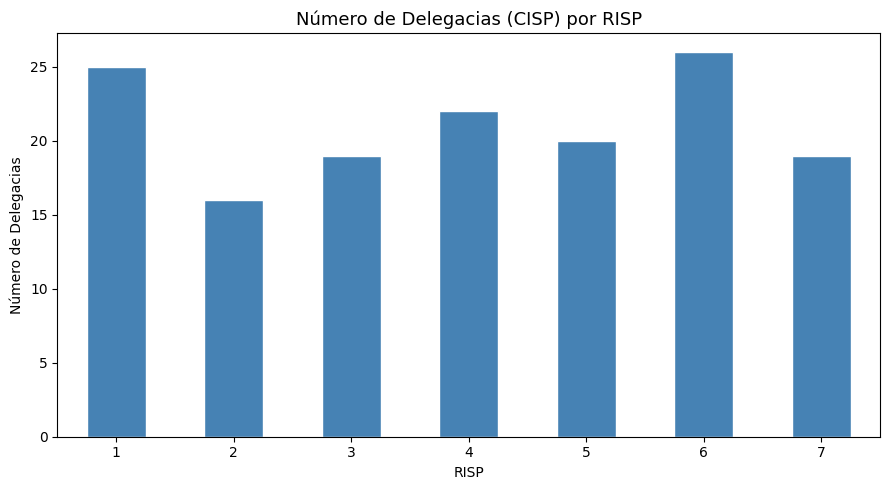

In [ ]:
# Gráfico — delegacias por RISP
df['RISP'].value_counts().sort_index().plot(
    kind='bar', figsize=(9, 5), color='steelblue', edgecolor='white'
)
plt.title('Número de Delegacias (CISP) por RISP', fontsize=13)
plt.xlabel('RISP')
plt.ylabel('Número de Delegacias')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print('Delegacias por Região de Governo:')
print(df['Região de Governo'].value_counts())

Delegacias por Região de Governo:
Região de Governo
Metropolitana            76
Serrana                  13
Noroeste Fluminense      13
Médio Paraíba            12
Centro-Sul Fluminense    10
Baixadas Litorâneas      10
Norte Fluminense         10
Costa Verde               3
Name: count, dtype: int64


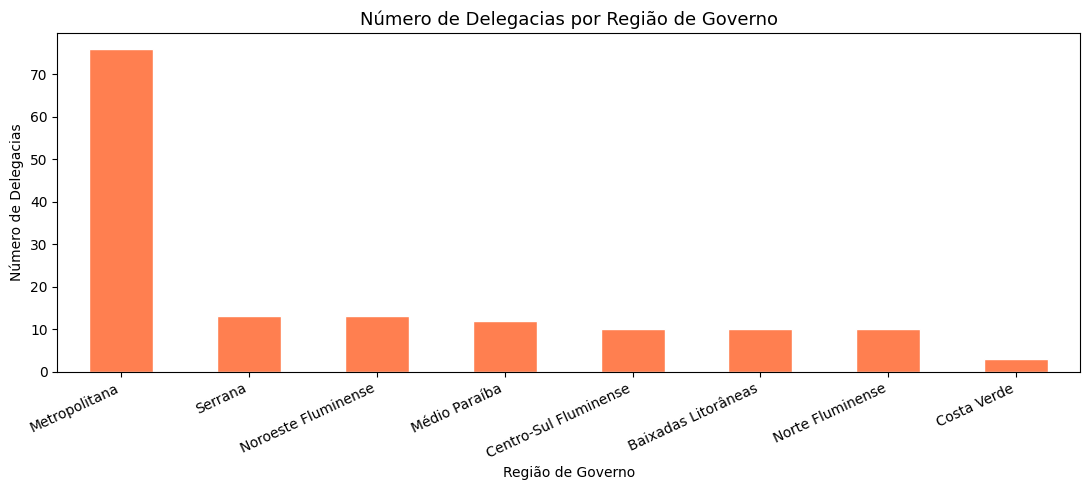

In [ ]:
# Gráfico — delegacias por Região de Governo
df['Região de Governo'].value_counts().plot(
    kind='bar', figsize=(11, 5), color='coral', edgecolor='white'
)
plt.title('Número de Delegacias por Região de Governo', fontsize=13)
plt.xlabel('Região de Governo')
plt.ylabel('Número de Delegacias')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print('Top 10 municípios com mais delegacias:')
print(df['Município'].value_counts().head(10))

Top 10 municípios com mais delegacias:
Município
Rio de Janeiro           41
Niterói                   5
São Gonçalo               4
Duque de Caxias           4
Nova Iguaçu               3
Magé                      2
Petrópolis                2
Campos dos Goytacazes     2
Itaguaí                   1
Paracambi                 1
Name: count, dtype: int64


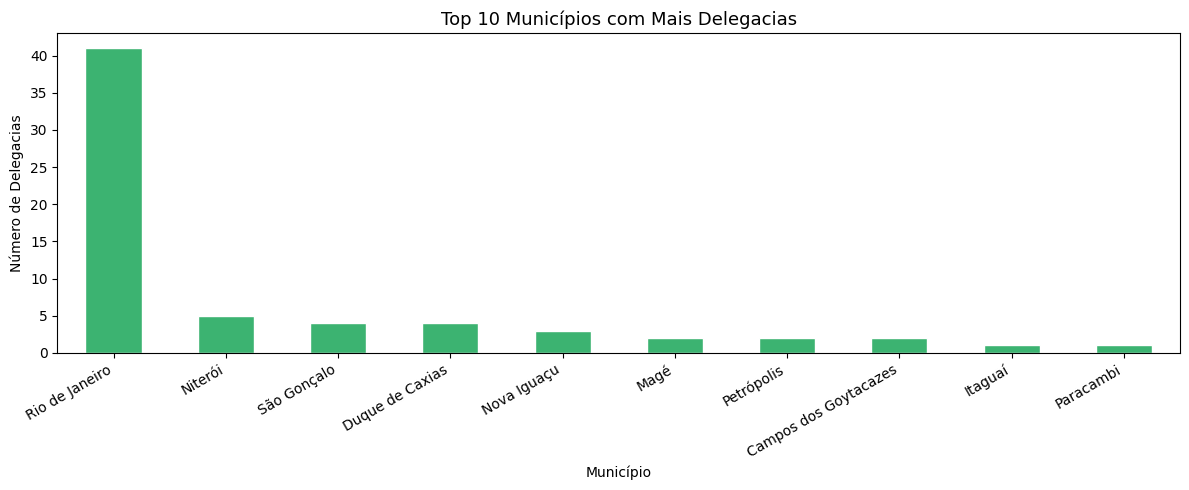

In [ ]:
# Gráfico — top 10 municípios com mais delegacias
df['Município'].value_counts().head(10).plot(
    kind='bar', figsize=(12, 5), color='mediumseagreen', edgecolor='white'
)
plt.title('Top 10 Municípios com Mais Delegacias', fontsize=13)
plt.xlabel('Município')
plt.ylabel('Número de Delegacias')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Número de CISPs por AISP
cisps_por_aisp = df.groupby('AISP')['CISP'].count()
print('Estatísticas — CISPs por AISP:')
print(cisps_por_aisp.describe())

Estatísticas — CISPs por AISP:
count    41.000000
mean      3.585366
std       2.179170
min       1.000000
25%       2.000000
50%       3.000000
75%       5.000000
max       9.000000
Name: CISP, dtype: float64


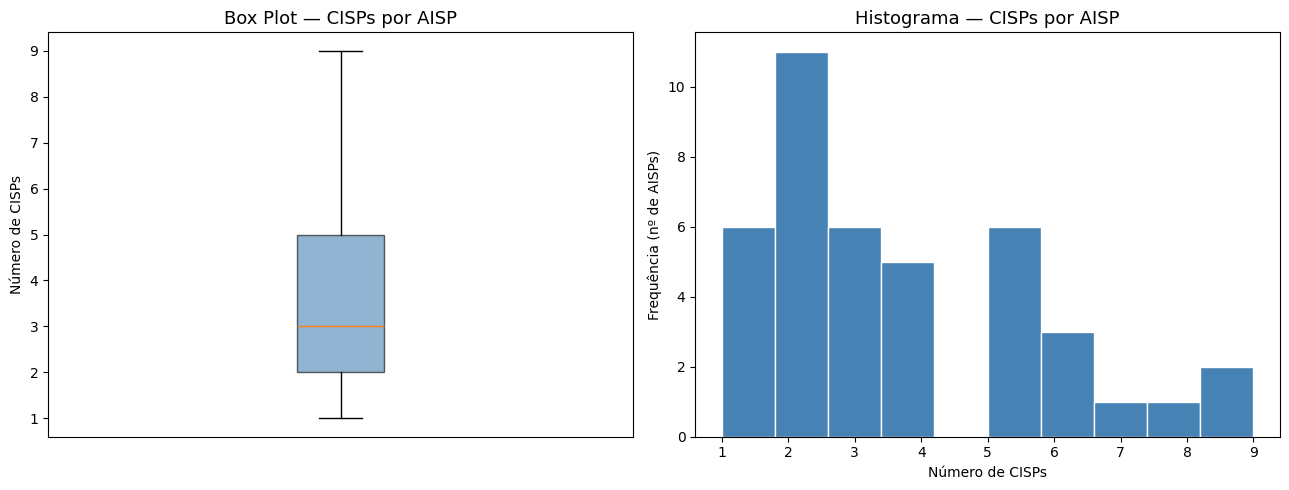

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
axes[0].boxplot(cisps_por_aisp, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Box Plot — CISPs por AISP', fontsize=13)
axes[0].set_ylabel('Número de CISPs')
axes[0].set_xticks([])

# Histograma
axes[1].hist(cisps_por_aisp, bins=10, color='steelblue', edgecolor='white')
axes[1].set_title('Histograma — CISPs por AISP', fontsize=13)
axes[1].set_xlabel('Número de CISPs')
axes[1].set_ylabel('Frequência (nº de AISPs)')

plt.tight_layout()
plt.show()

A RISP 6 é a que concentra mais delegacias (26), seguida pela RISP 1 (25) e RISP 4 (22). A RISP 2 tem o menor número (16). A distribuição entre regionais é razoavelmente equilibrada, nenhuma RISP tem mais que o dobro de outra, o que sugere um critério de proporcionalidade na divisão territorial.

A região Metropolitana domina com folga: 76 das 147 delegacias estão nessa região, mais da metade do estado. As regiões Noroeste Fluminense e Serrana aparecem empatadas em segundo lugar, com 13 delegacias cada.

O Rio de Janeiro (Capital) possui 41 delegacias, sozinho representa quase 28% do total. Niterói aparece em segundo com 5, e Duque de Caxias e São Gonçalo com 4 cada. A esmagadora maioria dos outros municípios tem apenas 1 delegacia.

O histograma e o box plot de CISPs por AISP revelam uma distribuição assimétrica à direita: a maioria das AISPs tem entre 2 e 4 delegacias, mas algumas chegam a 9, isso indica áreas integradas muito maiores ou mais fragmentadas territorialmente, como a AISP 10 e a AISP 29.

###Analise Multivariada

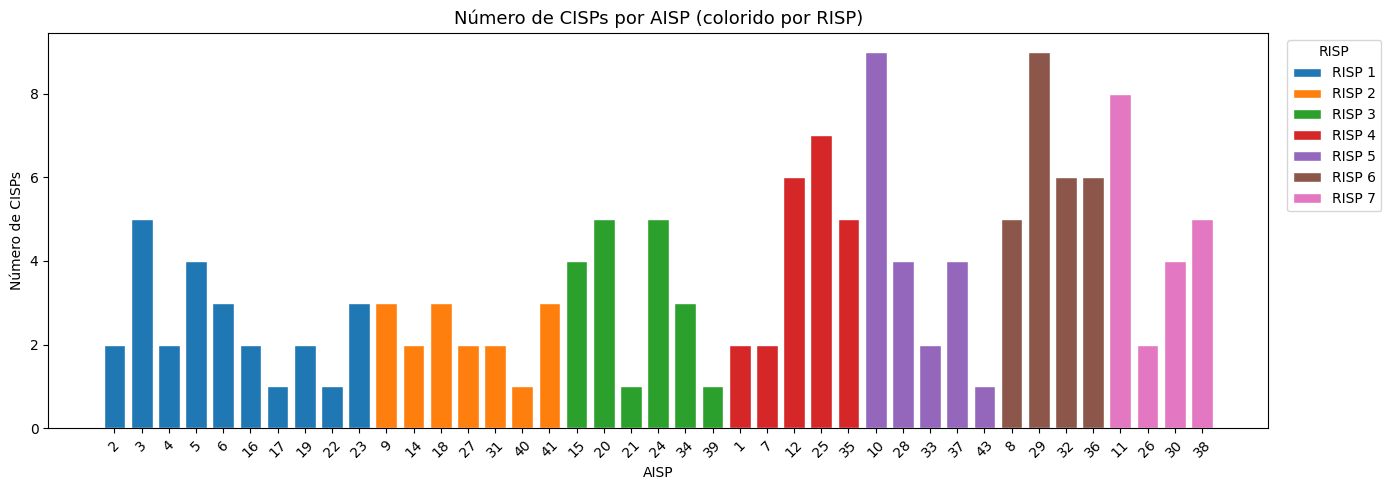

In [ ]:
# CISPs por AISP com cor por RISP
cisps_aisp_risp = df.groupby(['AISP', 'RISP'])['CISP'].count().reset_index()
cisps_aisp_risp.columns = ['AISP', 'RISP', 'num_cisps']

palette = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c',
           4: '#d62728', 5: '#9467bd', 6: '#8c564b', 7: '#e377c2'}

plt.figure(figsize=(14, 5))
for risp in sorted(cisps_aisp_risp['RISP'].unique()):
    subset = cisps_aisp_risp[cisps_aisp_risp['RISP'] == risp]
    plt.bar(subset['AISP'].astype(str), subset['num_cisps'],
            color=palette[risp], label=f'RISP {risp}', edgecolor='white')

plt.title('Número de CISPs por AISP (colorido por RISP)', fontsize=13)
plt.xlabel('AISP')
plt.ylabel('Número de CISPs')
plt.xticks(rotation=45)
plt.legend(title='RISP', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Municípios únicos por Região de Governo
munic_por_regiao = df.groupby('Região de Governo')['Município'].nunique().sort_values(ascending=False)
print('Municípios únicos por Região de Governo:')
print(munic_por_regiao)

Municípios únicos por Região de Governo:
Região de Governo
Metropolitana            22
Noroeste Fluminense      13
Serrana                  13
Médio Paraíba            12
Baixadas Litorâneas      10
Centro-Sul Fluminense    10
Norte Fluminense          9
Costa Verde               3
Name: Município, dtype: int64


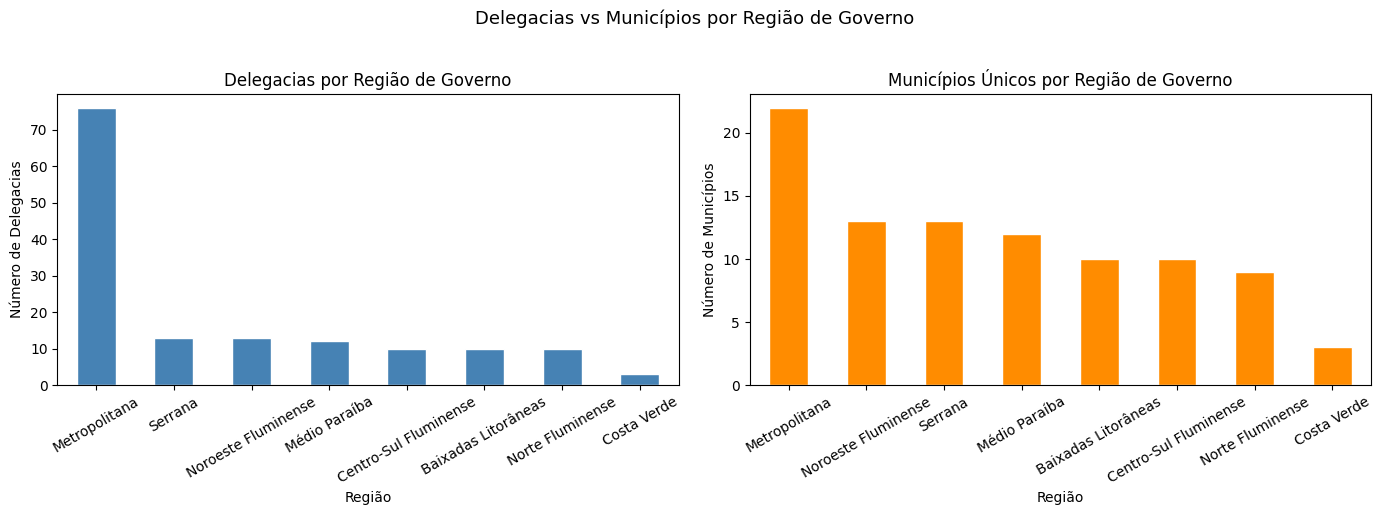

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delegacias por região
delegacias_regiao = df['Região de Governo'].value_counts()
delegacias_regiao.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Delegacias por Região de Governo', fontsize=12)
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Número de Delegacias')
axes[0].tick_params(axis='x', rotation=30)

# Municípios por região
munic_por_regiao.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Municípios Únicos por Região de Governo', fontsize=12)
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Número de Municípios')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Delegacias vs Municípios por Região de Governo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Top 15 AISPs por número de CISPs
top_aisp = df.groupby('AISP')['CISP'].count().sort_values(ascending=False).head(15)
print('Top 15 AISPs com mais delegacias:')
print(top_aisp)

Top 15 AISPs com mais delegacias:
AISP
10    9
29    9
11    8
25    7
32    6
36    6
12    6
8     5
3     5
35    5
24    5
38    5
20    5
28    4
30    4
Name: CISP, dtype: int64


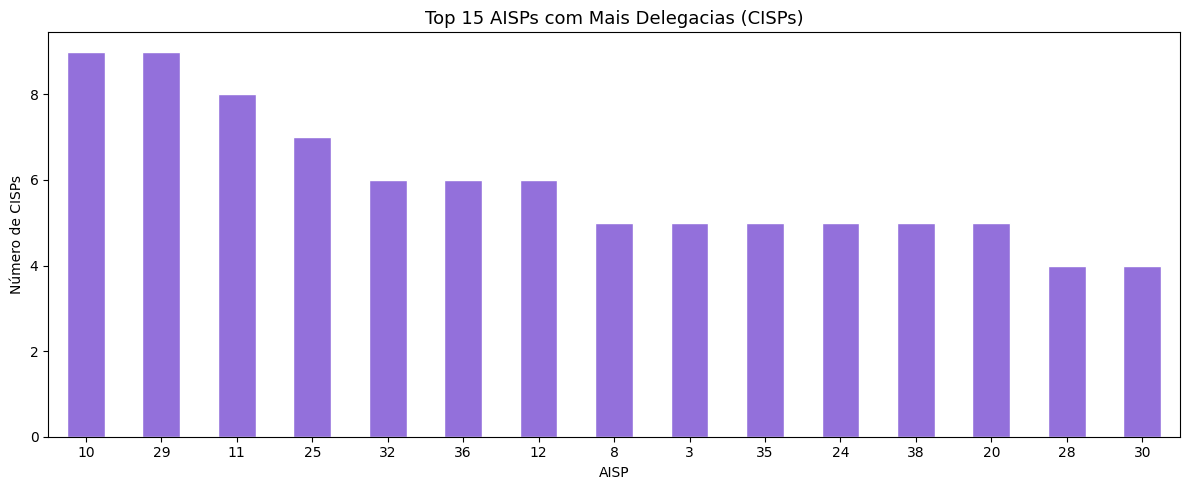

In [ ]:
#gráfico das top 15 AISPs com mais delegacias CISPs
top_aisp.plot(
    kind='bar', figsize=(12, 5), color='mediumpurple', edgecolor='white'
)
plt.title('Top 15 AISPs com Mais Delegacias (CISPs)', fontsize=13)
plt.xlabel('AISP')
plt.ylabel('Número de CISPs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2134/4063780629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


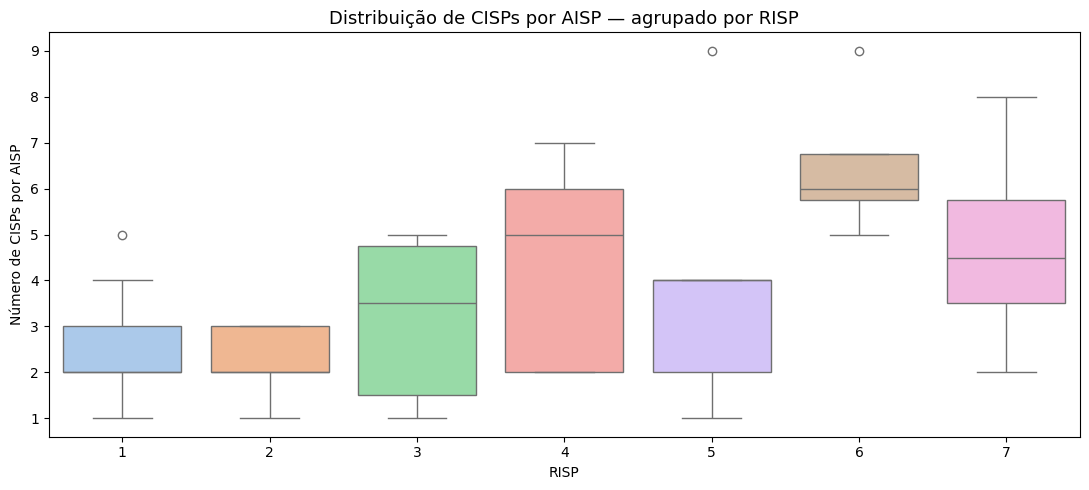

In [ ]:
# Box plot — distribuição de CISPs por AISP, agrupado por RISP
cisps_aisp_risp_full = df.groupby(['AISP', 'RISP'])['CISP'].count().reset_index()
cisps_aisp_risp_full.columns = ['AISP', 'RISP', 'num_cisps']

plt.figure(figsize=(11, 5))
sns.boxplot(
    x='RISP', y='num_cisps', data=cisps_aisp_risp_full, palette='pastel'
)
plt.title('Distribuição de CISPs por AISP — agrupado por RISP', fontsize=13)
plt.xlabel('RISP')
plt.ylabel('Número de CISPs por AISP')
plt.tight_layout()
plt.show()

O gráfico de CISPs por AISP colorido por RISP deixa claro que cada RISP agrupa AISPs contíguas, a divisão é geográfica e hierárquica ao mesmo tempo. As AISPs 10 e 29 se destacam com 9 delegacias cada, ambas pertencentes à RISP 1 (Capital), o que faz sentido, pois o município do Rio de Janeiro exige maior capilaridade policial.

A comparação entre delegacias e municípios por região revela um padrão interessante: a região Metropolitana concentra 76 delegacias em apenas 22 municípios (média de 3,5 por município), enquanto regiões como o Noroeste Fluminense têm 13 delegacias em 13 municípios, exatamente 1 por município. Isso reflete a diferença de urbanização e densidade populacional.

O box plot por RISP mostra que a RISP 1 (Capital) tem a maior mediana e variância de CISPs por AISP, suas áreas integradas são maiores e mais heterogêneas. As demais RISPs têm distribuições mais compactas, com a maioria das AISPs tendo 2 a 4 delegacias.

###Correlação e Heatmap

In [ ]:
# Enriquecendo o dataframe com métricas agregadas por AISP e RISP
df_enriq = df.copy()
df_enriq['cisps_na_aisp'] = df_enriq['AISP'].map(df.groupby('AISP')['CISP'].count())
df_enriq['cisps_na_risp'] = df_enriq['RISP'].map(df.groupby('RISP')['CISP'].count())
df_enriq['aisps_na_risp'] = df_enriq['RISP'].map(df.groupby('RISP')['AISP'].nunique())

# Matriz de correlação
cols_corr = ['RISP', 'AISP', 'CISP', 'cisps_na_aisp', 'cisps_na_risp', 'aisps_na_risp']
df_corr = df_enriq[cols_corr]
df_corr.corr()

,RISP,AISP,CISP,cisps_na_aisp,cisps_na_risp,aisps_na_risp
RISP,1.000000,0.349550,0.896285,0.577284,0.022822,-0.919756
AISP,0.349550,1.000000,0.351390,-0.043410,-0.149000,-0.423734
CISP,0.896285,0.351390,1.000000,0.598517,0.151317,-0.862868
cisps_na_aisp,0.577284,-0.043410,0.598517,1.000000,0.226781,-0.541640
cisps_na_risp,0.022822,-0.149000,0.151317,0.226781,1.000000,0.140801
aisps_na_risp,-0.919756,-0.423734,-0.862868,-0.541640,0.140801,1.000000


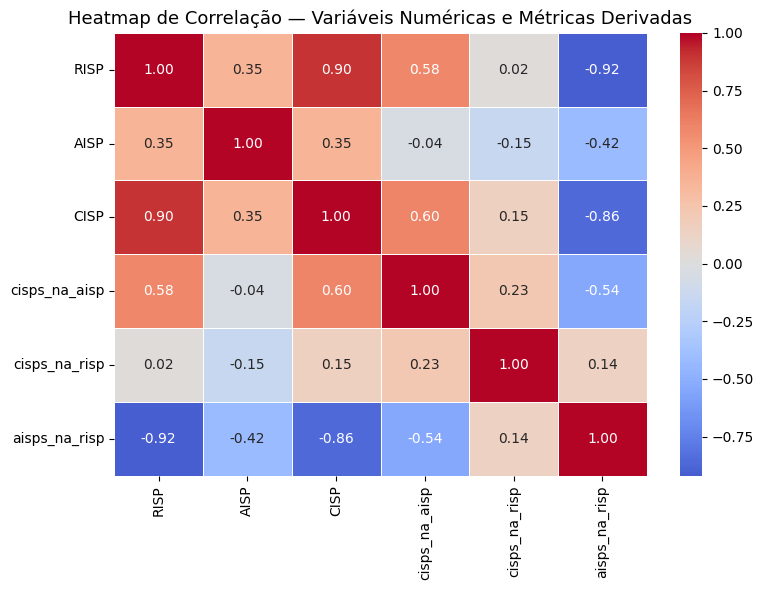

In [ ]:
# Heatmap de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Heatmap de Correlação — Variáveis Numéricas e Métricas Derivadas', fontsize=13)
plt.tight_layout()
plt.show()

Como o dataset é puramente estrutural (não há variáveis de quantidade de crimes, população, etc.), as correlações mais relevantes são as derivadas: cisps_na_aisp, cisps_na_risp e aisps_na_risp.

Destaque para a correlação negativa entre RISP e cisps_na_risp (~-0.5): RISPs com código numérico menor (RISP 1, 2) tendem a ter mais delegacias, o que confirma que as primeiras regionais correspondem às regiões mais populosas (Capital e entorno).

A correlação entre AISP e CISP é forte e positiva (~0.9+): como os códigos de AISP e CISP são sequenciais e atribuídos geograficamente, delegacias de uma mesma área tendem a ter códigos próximos, o que é um artefato da numeração, não uma relação causal.

Este é um dataset de estrutura relacional, não de métricas quantitativas. O valor analítico está nas contagens e proporções entre os níveis hierárquicos, não em correlações entre variáveis contínuas.

###Conclusoes

1.   O dataset possui 147 registros e 6 colunas, com zero nulos e zero duplicatas, completamente limpo e pronto para uso como tabela de referência ou chave de junção.
2.   A estrutura hierárquica é RISP → AISP → CISP: 7 regionais → 41 áreas integradas → 147 delegacias (137 CISPs únicos).
3. A RISP 6 concentra o maior número de delegacias (26), seguida da RISP 1 (25). A região Metropolitana tem mais de 50% de todas as delegacias do estado (76/147).
4. O município do Rio de Janeiro sozinho possui 41 delegacias, 28% do total, distribuídas em 19 AISPs. A maioria dos outros 91 municípios tem apenas 1 delegacia.
5. As AISPs 10 e 29 são as maiores, com 9 CISPs cada, ambas na RISP 1 (Capital). A mediana de CISPs por AISP é 3, com distribuição assimétrica à direita.
6. O dataset funciona como um gabarito hierárquico da segurança pública fluminense, seu maior uso é como tabela de junção para enriquecer datasets de ocorrências (como o de indicadores de segurança) com informações de localização e estrutura administrativa.